In [1]:
import jax
import tensorflow_probability.substrates.jax.bijectors as tfb
import tensorflow_probability.substrates.jax.distributions as tfd

import liesel.model as lsl
import liesel.optim as opt

We take a super simple Liesel model here

In [2]:
xval = 2.0 * jax.random.normal(jax.random.key(42), (10_000,)) + 3.0

In [3]:
m = lsl.Var.new_param(0.0, name="m")
s = lsl.Var.new_param(1.0, name="s")
s.transform(tfb.Exp())
x = lsl.Var.new_obs(
    xval,
    distribution=lsl.Dist(tfd.Normal, loc=m, scale=s),
    name="x",
)
p = lsl.Model([x])

In [4]:
engine = opt.LieselOptim(
    p, loss_monitor="train_full_data", optimizers="lbfgs"
).build_engine()

In [5]:
res = engine.fit()

Initializing:   0%|          | 0/1000 [00:00<?, ?it/s]

Train=2.105, Monitor=2.103:   1%|          | 10/1000 [00:00<00:43, 22.65it/s]

Train=2.103, Monitor=2.103:   2%|▏         | 20/1000 [00:00<00:27, 36.09it/s]

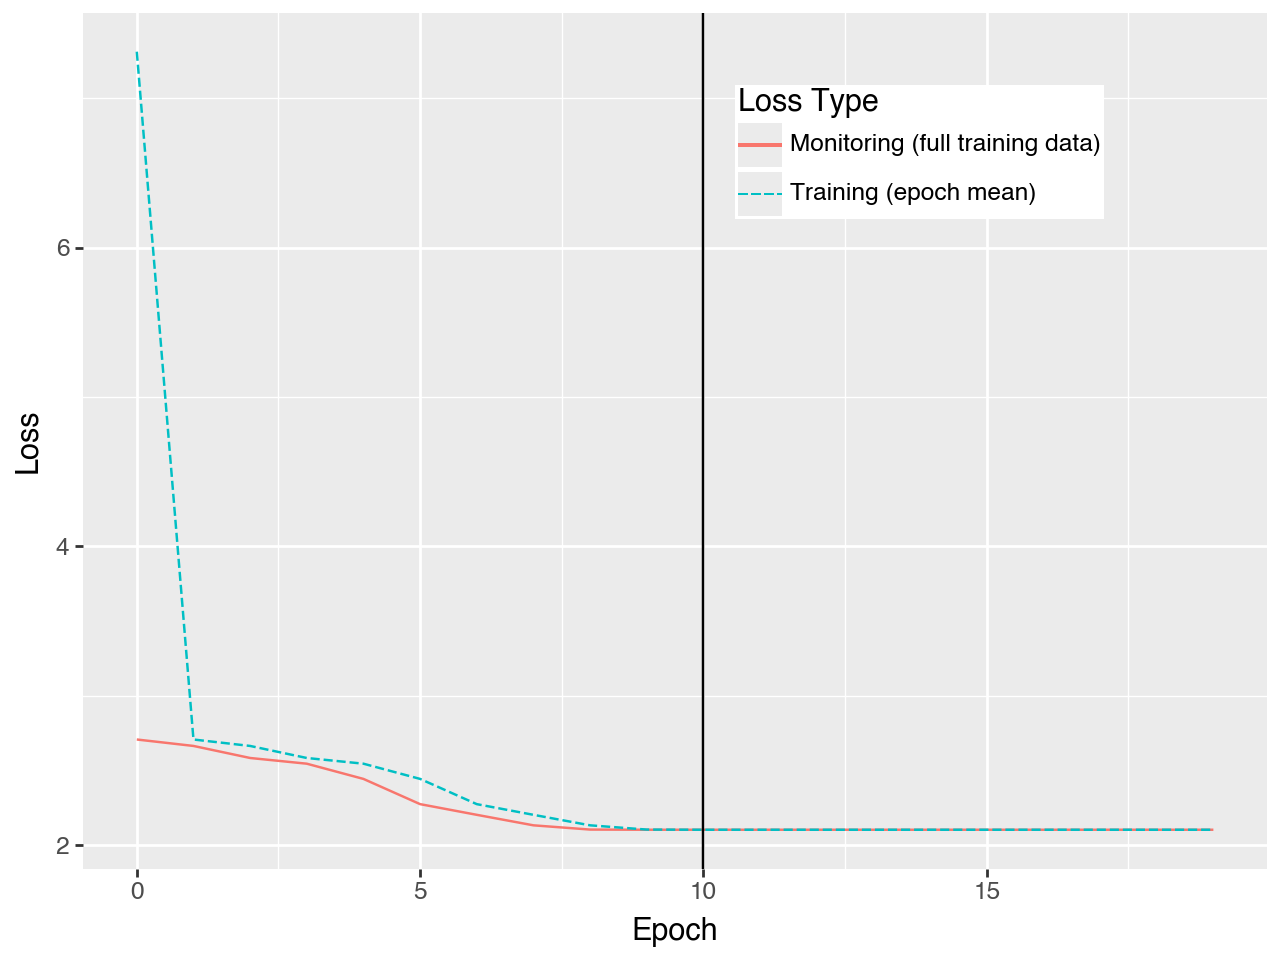

In [6]:
res.plot_loss()

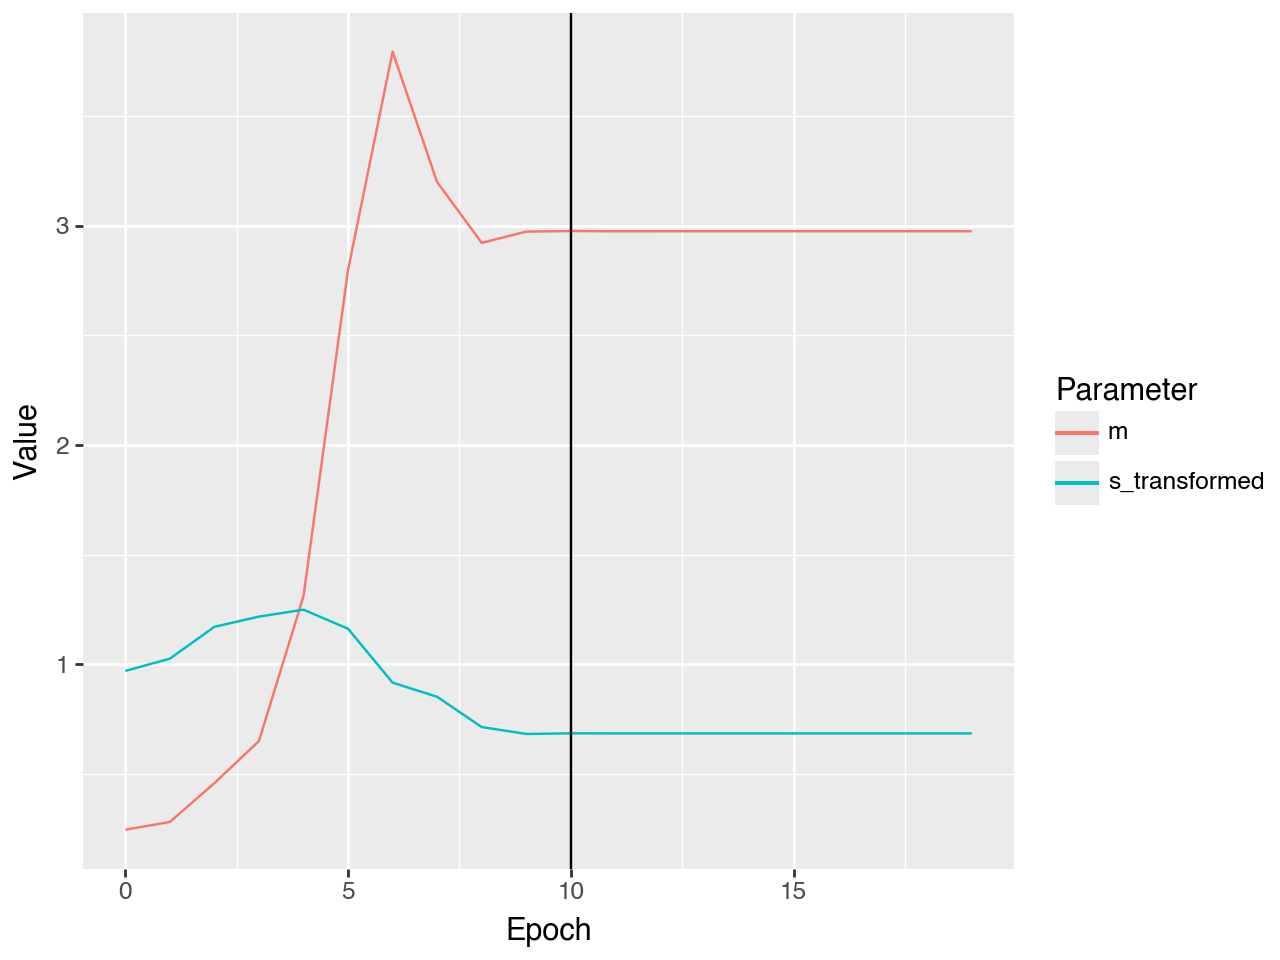

In [7]:
res.plot_params()

In [8]:
opt.PositionSplit.from_model(p, validate_axis_share=0.2)

PositionSplit(train=8000, validate=2000, test=0)

In [9]:
opt.Batches.from_model(p, 128)

Batches(axis_size=10000, batch_size=128, default_batch_axis=0)

In [10]:
split = opt.PositionSplit.from_model(p, validate_axis_share=0.1, shuffle=True)
engine = opt.LieselOptim(
    p,
    loss_monitor="validation",
    split=split,
    batch_size=32,
    optimizers="adam",
).build_engine()

In [11]:
result = engine.fit()

Initializing:   0%|          | 0/1000 [00:00<?, ?it/s]

Train=2.345, Monitor=2.334:   1%|          | 10/1000 [00:00<00:24, 41.03it/s]

Train=2.102, Monitor=2.120:   4%|▍         | 41/1000 [00:00<00:07, 123.87it/s]

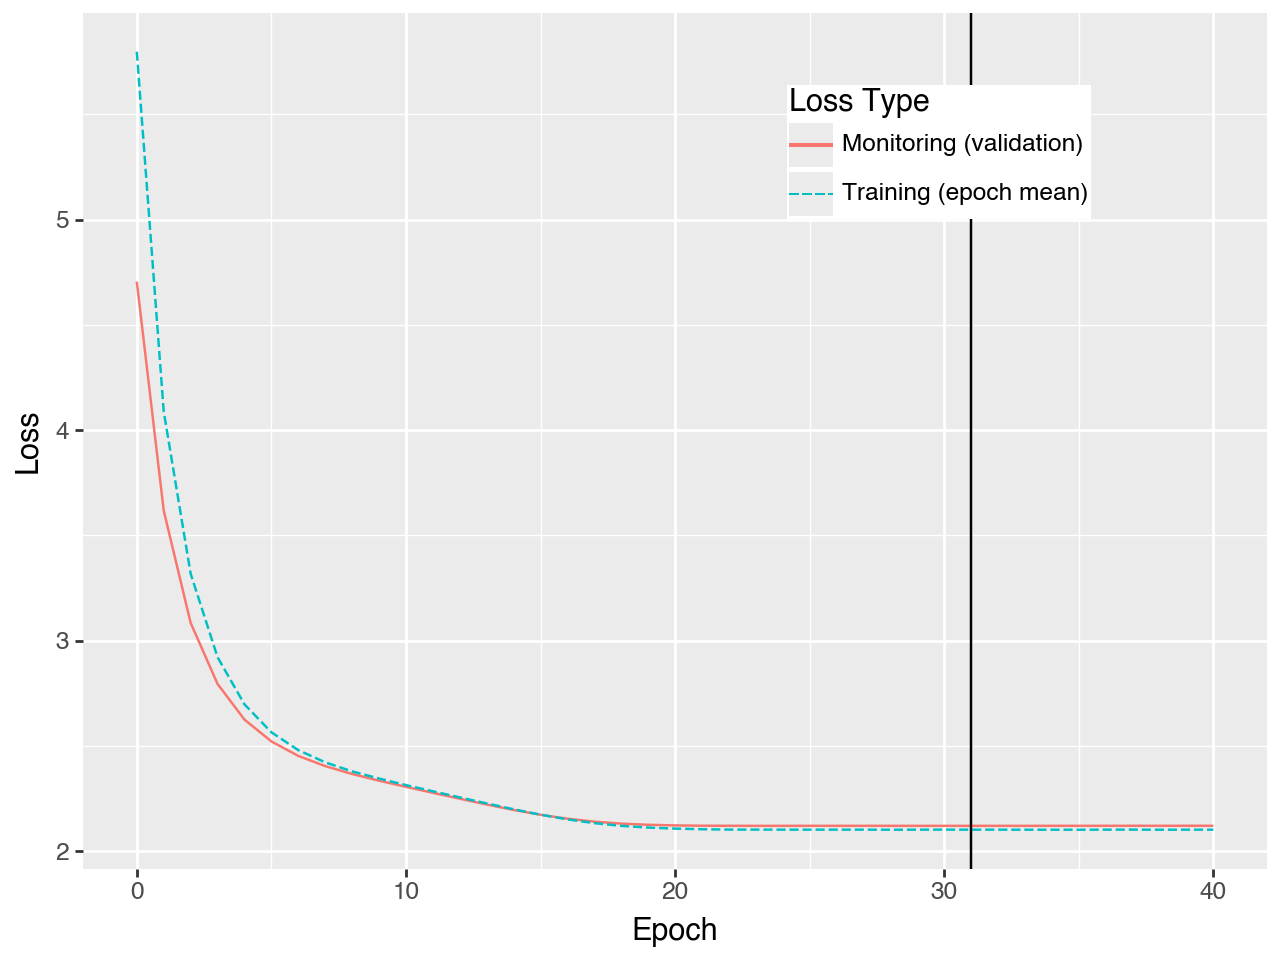

In [12]:
result.plot_loss()

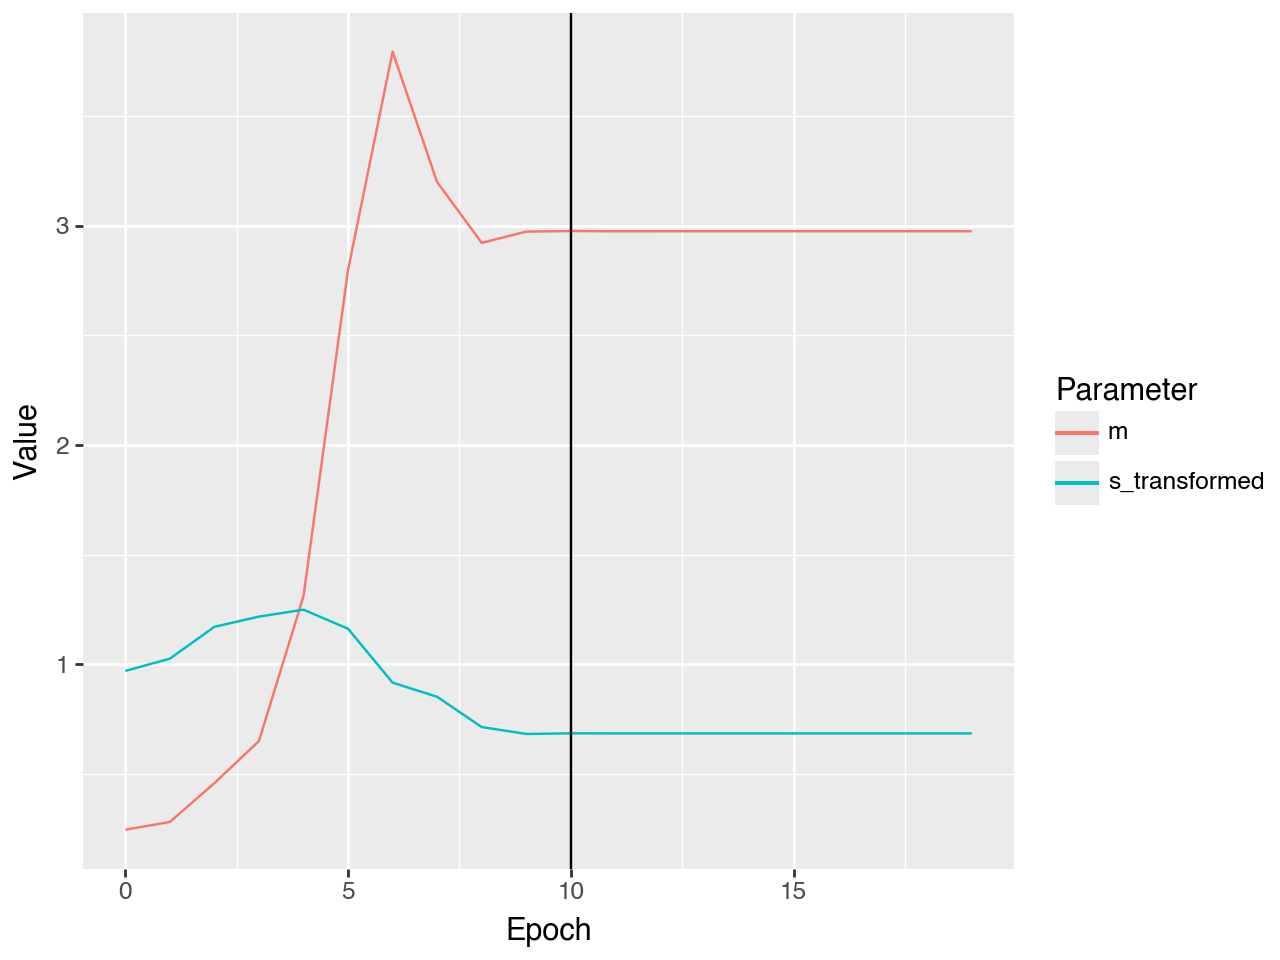

In [13]:
res.plot_params()